# OpenSky Trajectory Data Preview

This notebook loads a trajectory dataframe directly from the local scientific PostgreSQL database through `opensky_example.get_scientific_trajectory_df(...)`.

Use it to:
- retrieve raw or cleaned trajectory rows
- inspect dataframe columns and row counts
- summarize flights and coverage
- plot selected flights interactively


In [27]:
%matplotlib widget
# or: %matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import opensky_example

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd()
PROJECT_ROOT

PosixPath('/Users/anthonydills/gitprojects/example_pytorch')

## Retrieval Settings

Set the origin, duration threshold, optional time window, and optional cleaning filters here.

If `start_time` and `end_time` are left as `None`, the helper uses the actual available flight window from the scientific DB for that origin.


In [28]:
origin_airport = "EGLL"
minimum_duration_hours = 6

# Leave as None to use the full available scientific DB window for the origin.
start_time = None
end_time = None

# Optional cleaning filters.
apply_spike_filter = True
spike_min_deviation_m = 200.0
spike_max_window_seconds = 120.0

apply_gap_filter = True
gap_threshold_seconds = 600.0
gap_min_observed_fraction = 0.25

database_url = opensky_example.DEFAULT_DATABASE_URL

## Load Trajectory DataFrame

Loading the dataset can take around 28 minutes because the database is 26 GB.

In [29]:
trajectory_df = opensky_example.get_scientific_trajectory_df(
    origin_airport=origin_airport,
    minimum_duration_hours=minimum_duration_hours,
    start_time=start_time,
    end_time=end_time,
    database_url=database_url,
    apply_spike_filter=apply_spike_filter,
    spike_min_deviation_m=spike_min_deviation_m,
    spike_max_window_seconds=spike_max_window_seconds,
    apply_gap_filter=apply_gap_filter,
    gap_threshold_seconds=gap_threshold_seconds,
    gap_min_observed_fraction=gap_min_observed_fraction,
)

trajectory_df.shape

Using scientific DB flight window for EGLL: 2018-12-31 08:48:25 UTC to 2022-12-31 23:58:29 UTC.


(5421110, 25)

In [30]:
trajectory_df.head()

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,serials,hour,flight_key,origin,destination,first_seen,last_seen,duration_hours,source_backend
0,2020-05-25 00:18:20+00:00,c04fd7,52.187439,-59.472122,242.290563,239.787347,0.0,NaN,False,False,False,NaN,12192.0,12230.1,2020-05-25 00:18:13.459000+00:00,2020-05-25 00:18:19.210000+00:00,None,2020-05-25 00:00:00+00:00,c04fd7|ACA7201|2020-05-24T19:32:26+00:00,EGLL,CYUL,2020-05-24 19:32:26+00:00,2020-05-25 01:57:04+00:00,6.410556,scientific_db
1,2020-05-25 00:18:30+00:00,c04fd7,52.187439,-59.472122,242.290563,239.787347,0.0,NaN,False,False,False,NaN,12192.0,12230.1,2020-05-25 00:18:13.459000+00:00,2020-05-25 00:18:19.210000+00:00,None,2020-05-25 00:00:00+00:00,c04fd7|ACA7201|2020-05-24T19:32:26+00:00,EGLL,CYUL,2020-05-24 19:32:26+00:00,2020-05-25 01:57:04+00:00,6.410556,scientific_db
2,2020-05-25 00:18:40+00:00,c04fd7,52.163223,-59.539795,241.846138,239.726017,0.0,NaN,False,False,False,NaN,12192.0,12230.1,2020-05-25 00:18:35.088000+00:00,2020-05-25 00:18:35.088000+00:00,None,2020-05-25 00:00:00+00:00,c04fd7|ACA7201|2020-05-24T19:32:26+00:00,EGLL,CYUL,2020-05-24 19:32:26+00:00,2020-05-25 01:57:04+00:00,6.410556,scientific_db
3,2020-05-25 00:18:50+00:00,c04fd7,52.147817,-59.582546,241.401991,239.664461,0.0,ACA7201,False,False,False,0704,12192.0,12230.1,2020-05-25 00:18:49.983000+00:00,2020-05-25 00:18:49.983000+00:00,None,2020-05-25 00:00:00+00:00,c04fd7|ACA7201|2020-05-24T19:32:26+00:00,EGLL,CYUL,2020-05-24 19:32:26+00:00,2020-05-25 01:57:04+00:00,6.410556,scientific_db
4,2020-05-25 00:19:00+00:00,c04fd7,52.142044,-59.598633,241.401991,239.664461,0.0,ACA7201,False,False,False,0704,12192.0,12230.1,2020-05-25 00:18:59.221999+00:00,2020-05-25 00:18:59.221999+00:00,None,2020-05-25 00:00:00+00:00,c04fd7|ACA7201|2020-05-24T19:32:26+00:00,EGLL,CYUL,2020-05-24 19:32:26+00:00,2020-05-25 01:57:04+00:00,6.410556,scientific_db


In [31]:
trajectory_df.dtypes

time              datetime64[us, UTC]
icao24                            str
lat                           float64
lon                           float64
velocity                      float64
heading                       float64
vertrate                      float64
callsign                          str
onground                         bool
alert                            bool
spi                              bool
squawk                            str
baroaltitude                  float64
geoaltitude                   float64
lastposupdate     datetime64[us, UTC]
lastcontact       datetime64[us, UTC]
serials                        object
hour              datetime64[us, UTC]
flight_key                        str
origin                            str
destination                       str
first_seen        datetime64[us, UTC]
last_seen         datetime64[us, UTC]
duration_hours                float64
source_backend                    str
dtype: object

## Create Basic Dataset Summary
1. Assigns columns for summary
2. Creates summary DataFrame based upon groupings of summary columns
3. Computes observed hours (`observed_hours`) of the total flight
4. Computes fraction of hours observed (`observed_hours/duration_hours`)
5. Prints sorted view of flights according to the largest observed fraction.

In [32]:
summary = {
    "rows": len(trajectory_df),
    "flights": trajectory_df["flight_key"].nunique() if not trajectory_df.empty else 0,
    "origins": trajectory_df["origin"].dropna().unique().tolist() if "origin" in trajectory_df else [],
    "destinations": trajectory_df["destination"].nunique() if "destination" in trajectory_df else 0,
    "min_time": trajectory_df["time"].min() if not trajectory_df.empty else pd.NaT,
    "max_time": trajectory_df["time"].max() if not trajectory_df.empty else pd.NaT,
}
summary

{'rows': 5421110,
 'flights': 5170,
 'origins': ['EGLL'],
 'destinations': 125,
 'min_time': Timestamp('2020-05-25 00:18:20+0000', tz='UTC'),
 'max_time': Timestamp('2022-06-27 23:59:50+0000', tz='UTC')}

In [33]:
flight_summary_df = (
    trajectory_df.groupby(["flight_key", "callsign", "origin", "destination"], dropna=False)
    .agg(
        first_time=("time", "min"),
        last_time=("time", "max"),
        row_count=("time", "size"),
        first_seen=("first_seen", "min"),
        last_seen=("last_seen", "max"),
        duration_hours=("duration_hours", "max"),
    )
    .reset_index()
)

flight_summary_df["observed_hours"] = (
    flight_summary_df["last_time"] - flight_summary_df["first_time"]
).dt.total_seconds() / 3600
flight_summary_df["observed_fraction"] = (
    flight_summary_df["observed_hours"] / flight_summary_df["duration_hours"]
)

flight_summary_df.sort_values(["observed_fraction", "row_count"], ascending=[False, False]).head(20)

,flight_key,callsign,origin,destination,first_time,last_time,row_count,first_seen,last_seen,duration_hours,observed_hours,observed_fraction
1480,406947|BAW169|2021-02-01T15:16:29+00:00,BAW169,EGLL,NaN,2021-02-01 15:16:30+00:00,2021-02-01 19:51:10+00:00,1499,2021-02-01 15:16:29+00:00,2021-02-01 21:23:45+00:00,6.121111,4.577778,0.747867
858,4006c4|BAW125|2020-10-12T10:53:30+00:00,BAW125,EGLL,OBBI,2020-10-12 10:53:30+00:00,2020-10-12 15:39:50+00:00,1714,2020-10-12 10:53:30+00:00,2020-10-12 17:19:38+00:00,6.435556,4.772222,0.741540
3066,4074e4|BAW125|2021-05-24T12:03:36+00:00,BAW125,EGLL,OBBI,2021-05-24 12:03:40+00:00,2021-05-24 16:26:20+00:00,1568,2021-05-24 12:03:36+00:00,2021-05-24 18:07:44+00:00,6.068889,4.377778,0.721347
1448,406891|BAW125|2020-11-09T11:37:14+00:00,BAW125,EGLL,OBBI,2020-11-09 11:37:20+00:00,2020-11-09 15:59:50+00:00,1572,2020-11-09 11:37:14+00:00,2020-11-09 17:41:15+00:00,6.066944,4.375000,0.721121
2851,40731c|BAW125|2021-02-22T11:44:04+00:00,BAW125,EGLL,OBBI,2021-02-22 11:44:10+00:00,2021-02-22 15:59:50+00:00,1531,2021-02-22 11:44:04+00:00,2021-02-22 17:48:38+00:00,6.076111,4.261111,0.701289
2849,40731c|BAW125|2020-10-26T11:50:03+00:00,BAW125,EGLL,OBBI,2020-10-26 11:50:10+00:00,2020-10-26 16:07:00+00:00,1503,2020-10-26 11:50:03+00:00,2020-10-26 17:56:59+00:00,6.115556,4.280556,0.699945
4039,7103d7|SVA106|2021-07-26T11:43:09+00:00,SVA106,EGLL,OERK,2021-07-26 11:43:10+00:00,2021-07-26 15:59:50+00:00,1223,2021-07-26 11:43:09+00:00,2021-07-26 17:52:27+00:00,6.155000,4.277778,0.695009
3068,4074e4|BAW125|2021-10-11T12:05:59+00:00,BAW125,EGLL,OBBI,2021-10-11 12:06:10+00:00,2021-10-11 16:21:50+00:00,1453,2021-10-11 12:05:59+00:00,2021-10-11 18:16:58+00:00,6.183056,4.261111,0.689159
2629,406f79|BAW125|2021-11-29T14:12:30+00:00,BAW125,EGLL,OBBI,2021-11-29 14:12:30+00:00,2021-11-29 18:24:20+00:00,1485,2021-11-29 14:12:30+00:00,2021-11-29 20:18:43+00:00,6.103611,4.197222,0.687662
3018,4074e2|BAW125|2021-10-25T11:47:30+00:00,BAW125,EGLL,OBBI,2021-10-25 11:47:30+00:00,2021-10-25 15:59:50+00:00,1458,2021-10-25 11:47:30+00:00,2021-10-25 17:54:46+00:00,6.121111,4.205556,0.687058


## Flight Summary Data Descriptions
1. Computes Distributions of "row_count", "observed_fraction"
2. How many flights with at least a certain amount of observed fraction
3. Plots histograms of row_count and observed_fraction records

In [ ]:
flight_summary_df["row_count"].describe()

count    5163.000000
mean      686.848150
std       541.705383
min         1.000000
25%         7.000000
50%       819.000000
75%      1181.000000
max      1987.000000
Name: row_count, dtype: float64

In [15]:
flight_summary_df["observed_fraction"].describe()

count    5163.000000
mean        0.265800
std         0.196664
min         0.000000
25%         0.008500
50%         0.293993
75%         0.410052
max         0.747867
Name: observed_fraction, dtype: float64

In [60]:
# number of flights above `observed_frac` observed:
observed_frac = 0.7
flight_summary_df.loc[flight_summary_df.observed_fraction > observed_frac, "observed_fraction"].describe()
# flight_summary_df["observed_fraction"].describe()

count    5.000000
mean     0.726633
std      0.018532
min      0.701289
25%      0.721121
50%      0.721347
75%      0.741540
max      0.747867
Name: observed_fraction, dtype: float64

In [64]:
flight_summary_df.loc[flight_summary_df.observed_fraction > observed_frac, ["flight_key", "observed_hours","observed_fraction"]].sort_values(["observed_fraction"], ascending=[False])

,flight_key,observed_hours,observed_fraction
1480,406947|BAW169|2021-02-01T15:16:29+00:00,4.577778,0.747867
858,4006c4|BAW125|2020-10-12T10:53:30+00:00,4.772222,0.741540
3066,4074e4|BAW125|2021-05-24T12:03:36+00:00,4.377778,0.721347
1448,406891|BAW125|2020-11-09T11:37:14+00:00,4.375000,0.721121
2851,40731c|BAW125|2021-02-22T11:44:04+00:00,4.261111,0.701289


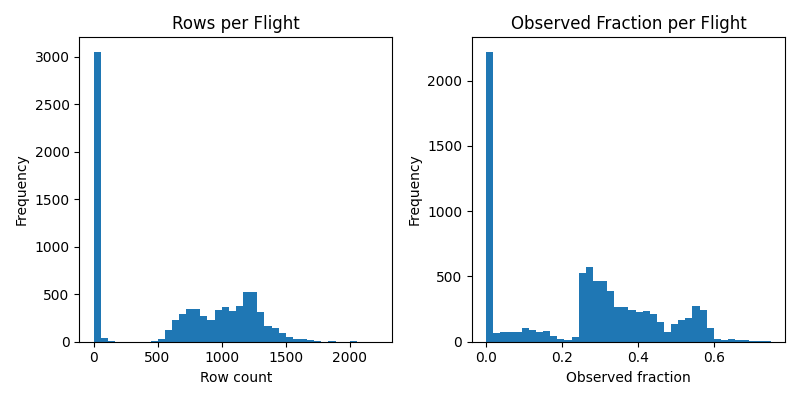

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
flight_summary_df["row_count"].plot.hist(bins=40, ax=axes[0], title="Rows per Flight")
flight_summary_df["observed_fraction"].plot.hist(bins=40, ax=axes[1], title="Observed Fraction per Flight")
axes[0].set_xlabel("Row count")
axes[1].set_xlabel("Observed fraction")
plt.tight_layout()
plt.show()

## Inspect a Single Flight


In [65]:
selected_flight_key = flight_summary_df.iloc[1480]["flight_key"]
selected_flight_key

'406947|BAW169|2021-02-01T15:16:29+00:00'

In [68]:
flight_df = (
    trajectory_df.loc[trajectory_df["flight_key"] == selected_flight_key]
    .sort_values("time")
    .copy()
)
# flight_df.head(20)

In [69]:
flight_df["plot_altitude_m"] = opensky_example.select_altitude_for_plot(flight_df)
flight_df["hours_since_takeoff"] = (
    pd.to_datetime(flight_df["time"], utc=True)
    - pd.to_datetime(flight_df["first_seen"], utc=True)
).dt.total_seconds() / 3600



In [71]:
flight_df[["hours_since_takeoff", "plot_altitude_m", "lat", "lon", "velocity", "heading", "vertrate"]].tail()

,hours_since_takeoff,plot_altitude_m,lat,lon,velocity,heading,vertrate
1459528,4.566944,10355.58,56.013885,67.292092,272.106351,98.589684,0.0
1459529,4.569722,10355.58,56.013885,67.292092,272.106351,98.589684,0.0
1459530,4.572500,10355.58,56.013885,67.292092,272.106351,98.589684,0.0
1459531,4.575278,10355.58,56.013885,67.292092,272.106351,98.589684,0.0
1459532,4.578056,10355.58,56.013885,67.292092,272.106351,98.589684,0.0


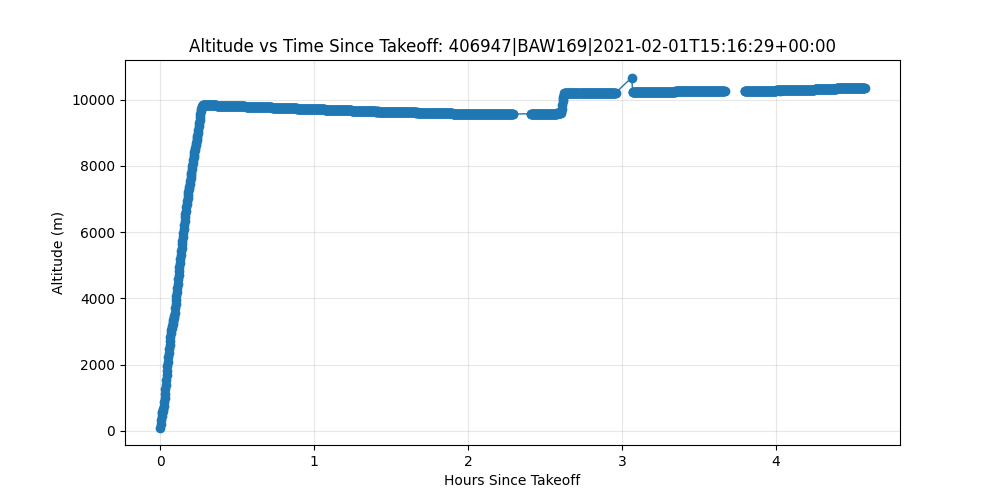

In [73]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(flight_df["hours_since_takeoff"], flight_df["plot_altitude_m"], marker="o", linewidth=1)
ax.set_title(f"Altitude vs Time Since Takeoff: {selected_flight_key}")
ax.set_xlabel("Hours Since Takeoff")
ax.set_ylabel("Altitude (m)")
ax.grid(True, alpha=0.3)
plt.show()

## Filtered flights above fraction observed

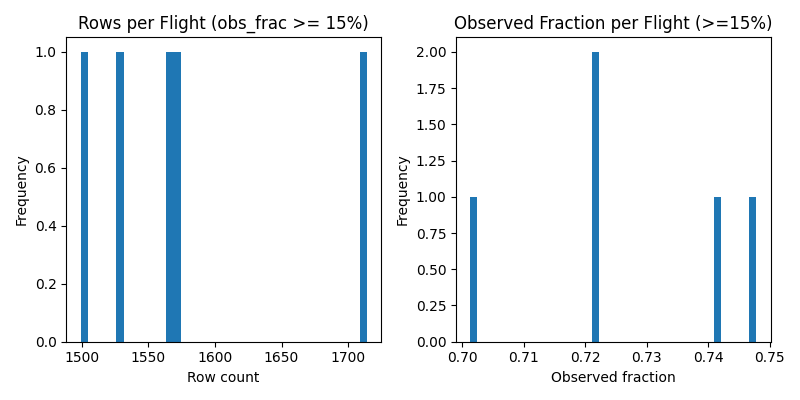

In [76]:
filtered = flight_summary_df[flight_summary_df["observed_fraction"] >= observed_frac]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
filtered["row_count"].plot.hist(bins=40, ax=axes[0], title="Rows per Flight (obs_frac >= 15%)")
filtered["observed_fraction"].plot.hist(bins=40, ax=axes[1], title="Observed Fraction per Flight (>=15%)")
axes[0].set_xlabel("Row count")
axes[1].set_xlabel("Observed fraction")
plt.tight_layout()
plt.show()

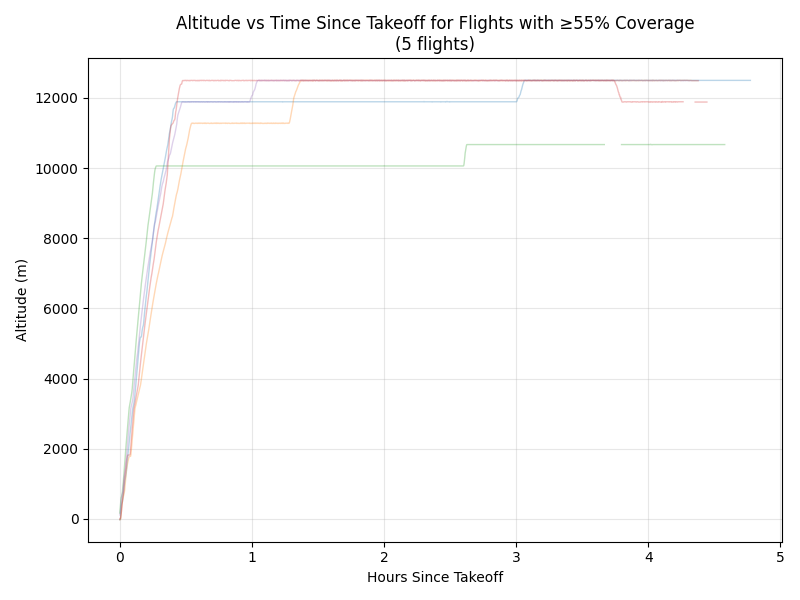

In [78]:
# Filter for flights with at least 55% observed fraction
high_coverage_flights = flight_summary_df[flight_summary_df["observed_fraction"] >= observed_frac]

fig, ax = plt.subplots(figsize=(8, 6))

# Plot altitude vs time for each high-coverage flight
for flight_key in high_coverage_flights["flight_key"]:
    flight_data = trajectory_df[trajectory_df["flight_key"] == flight_key].sort_values("time").copy()
    
    # Skip if no altitude data
    if flight_data["baroaltitude"].isna().all():
        continue
    
    # Calculate hours since takeoff
    flight_data["hours_since_takeoff"] = (
        pd.to_datetime(flight_data["time"], utc=True)
        - pd.to_datetime(flight_data["first_seen"], utc=True)
    ).dt.total_seconds() / 3600
    
    # Plot with transparency to see overlapping lines
    ax.plot(flight_data["hours_since_takeoff"], flight_data["baroaltitude"], 
            alpha=0.3, linewidth=1)

ax.set_xlabel("Hours Since Takeoff")
ax.set_ylabel("Altitude (m)")
ax.set_title(f"Altitude vs Time Since Takeoff for Flights with ≥55% Coverage\n({len(high_coverage_flights)} flights)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Apply stricter altitude spike filtering

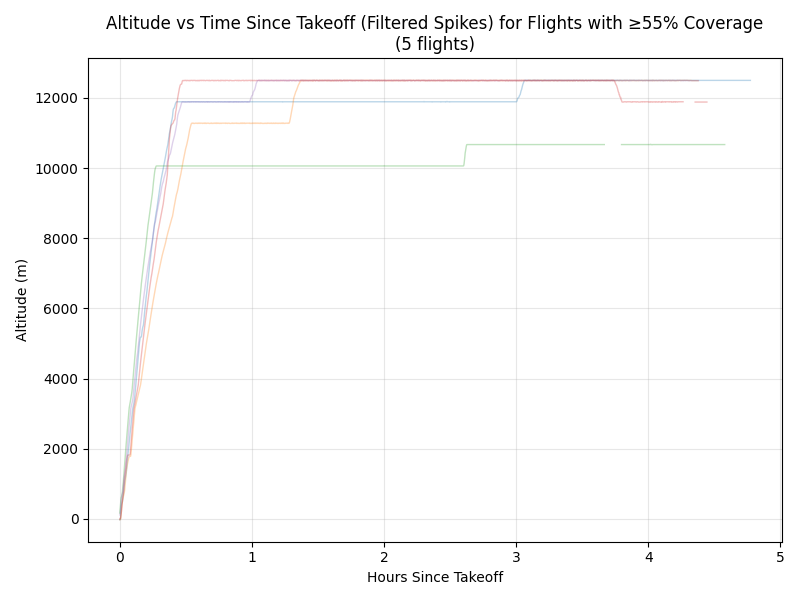

In [79]:
spike_min_deviation_m = 50.0
spike_max_window_seconds = 180.0
trajectory_df_filtered = opensky_example.filter_flight_altitude_spikes(
    trajectory_df,
    minimum_deviation_m=spike_min_deviation_m,
    max_window_seconds=spike_max_window_seconds
)

# Recalculate high coverage flights from filtered data
high_coverage_flights_filtered = flight_summary_df[flight_summary_df["observed_fraction"] >= observed_frac]

fig, ax = plt.subplots(figsize=(8, 6))

# Plot altitude vs time for each high-coverage flight using filtered data
for flight_key in high_coverage_flights_filtered["flight_key"]:
    flight_data_filtered = (
        trajectory_df_filtered[trajectory_df_filtered["flight_key"] == flight_key]
        .sort_values("time")
        .copy()
    )
    
    # Skip if no altitude data
    if flight_data_filtered["baroaltitude"].isna().all():
        continue
    
    # Calculate hours since takeoff
    flight_data_filtered["hours_since_takeoff"] = (
        pd.to_datetime(flight_data_filtered["time"], utc=True)
        - pd.to_datetime(flight_data_filtered["first_seen"], utc=True)
    ).dt.total_seconds() / 3600
    
    # Plot with transparency to see overlapping lines
    ax.plot(flight_data_filtered["hours_since_takeoff"], flight_data_filtered["baroaltitude"], 
            alpha=0.3, linewidth=1)

ax.set_xlabel("Hours Since Takeoff")
ax.set_ylabel("Altitude (m)")
ax.set_title(f"Altitude vs Time Since Takeoff (Filtered Spikes) for Flights with ≥55% Coverage\n({len(high_coverage_flights_filtered)} flights)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Archive

flight_df = trajectory_df[trajectory_df["flight_key"] == selected_flight_key].sort_values("time").copy()
flight_df["altitude_m"] = opensky_example.select_altitude_for_plot(flight_df)
flight_df["delta_t_s"] = pd.to_datetime(flight_df["time"], utc=True).diff().dt.total_seconds()
flight_df["delta_alt_m"] = flight_df["altitude_m"].diff()
flight_df["vertical_rate_mps"] = flight_df["delta_alt_m"] / flight_df["delta_t_s"]
flight_df[["time", "altitude_m", "delta_t_s", "delta_alt_m", "vertical_rate_mps"]].head(50)